In [110]:
# Save the Model
import os
import joblib

model_save_path = 'model_gbm.joblib'
joblib.dump(gbm_model, model_save_path)
print(f'GBM model saved to {model_save_path}')

# Save results to CSV
results_df = pd.DataFrame([gbm_results])
results_df.to_csv('gbm_results.csv', index=False)
print('Results saved to gbm_results.csv')

GBM model saved to model_gbm.joblib
Results saved to gbm_results.csv


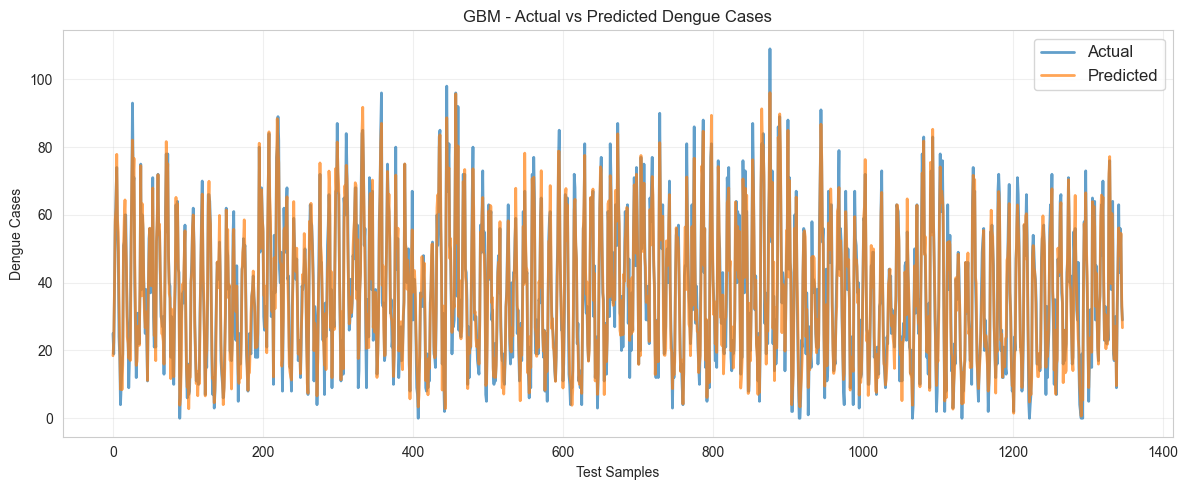

In [111]:
# Actual vs Predicted Plot
plt.figure(figsize=(12, 5))
plt.plot(list(y_test.values), label='Actual', alpha=0.7, linewidth=2)
plt.plot(list(y_pred), label='Predicted', alpha=0.7, linewidth=2)
plt.xlabel('Test Samples')
plt.ylabel('Dengue Cases')
plt.legend(fontsize=12)
plt.title('GBM - Actual vs Predicted Dengue Cases')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

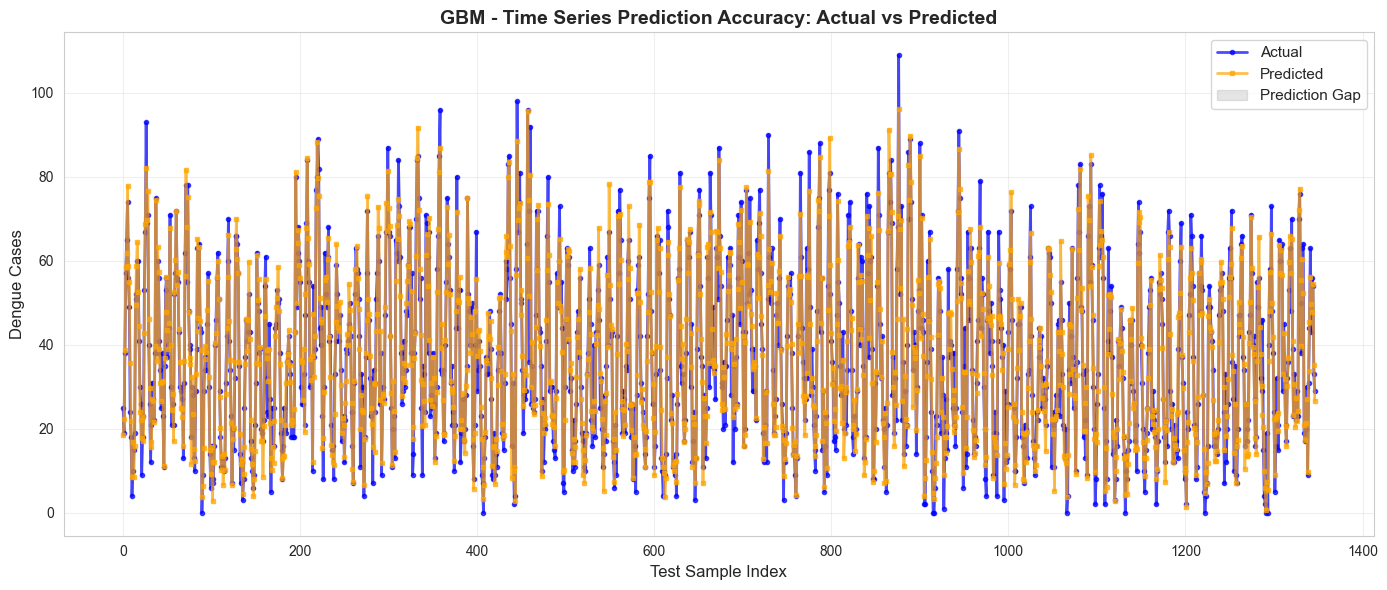

In [112]:
# Prediction Accuracy by Range
# Create bins for actual values
test_indices = np.arange(len(y_test))
sorted_indices = np.argsort(y_test.values)

plt.figure(figsize=(14, 6))
plt.plot(test_indices, y_test.values, label='Actual', alpha=0.7, linewidth=2, color='blue', marker='o', markersize=3)
plt.plot(test_indices, y_pred, label='Predicted', alpha=0.7, linewidth=2, color='orange', marker='s', markersize=3)
plt.fill_between(test_indices, y_test.values, y_pred, alpha=0.2, color='gray', label='Prediction Gap')
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Dengue Cases', fontsize=12)
plt.title('GBM - Time Series Prediction Accuracy: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

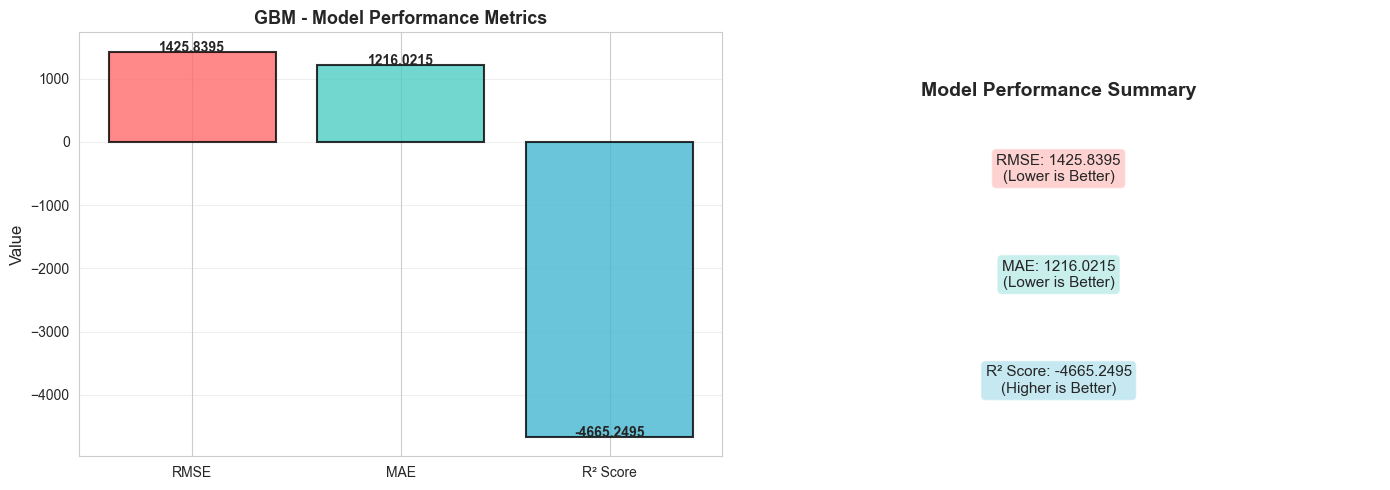

In [113]:
# Metrics Summary Visualization
metrics_data = {
    'Metric': ['RMSE', 'MAE', 'R² Score'],
    'Value': [rmse, mae, r2],
    'Normalized': [rmse/100, mae/100, r2]  # For visualization scaling
}
metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of raw values
colors_list = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0].bar(metrics_df['Metric'], metrics_df['Value'], color=colors_list, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('GBM - Model Performance Metrics', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(metrics_df['Value']):
    axes[0].text(i, v + 0.1, f'{v:.4f}', ha='center', fontweight='bold')

# Metric descriptions
metric_info = [
    f'RMSE: {rmse:.4f}\n(Lower is Better)',
    f'MAE: {mae:.4f}\n(Lower is Better)',
    f'R² Score: {r2:.4f}\n(Higher is Better)'
]
axes[1].axis('off')
axes[1].text(0.5, 0.85, 'Model Performance Summary', ha='center', fontsize=14, fontweight='bold')
for i, info in enumerate(metric_info):
    axes[1].text(0.5, 0.65 - i*0.25, info, ha='center', fontsize=11, 
                bbox=dict(boxstyle='round', facecolor=colors_list[i], alpha=0.3))

plt.tight_layout()
plt.show()

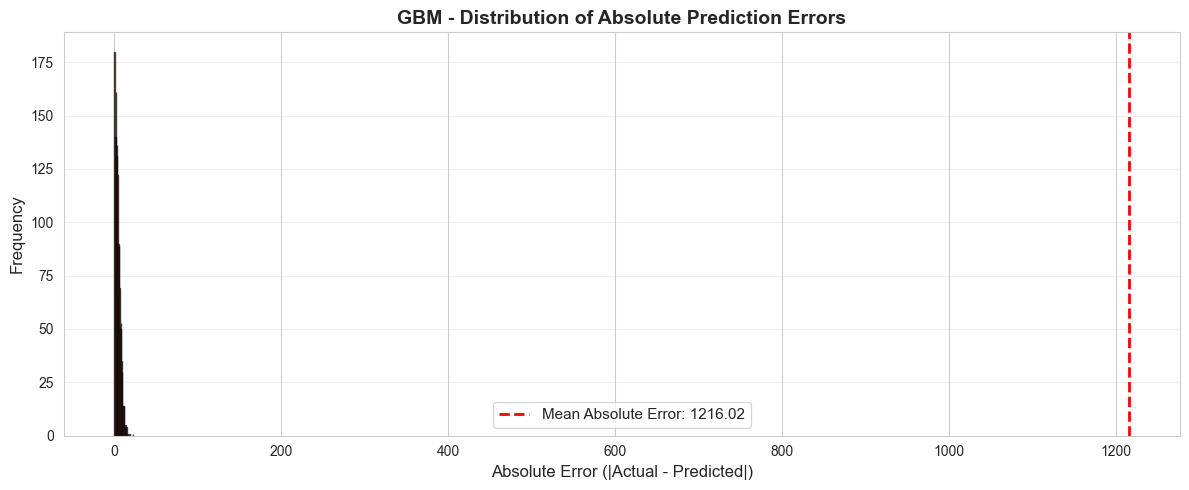

Max Error: 22.7067
Min Error: 0.0075
Median Error: 3.3087


In [114]:
# Prediction Error Distribution
residuals = y_test.values - y_pred
errors = np.abs(residuals)
plt.figure(figsize=(12, 5))
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Absolute Error (|Actual - Predicted|)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('GBM - Distribution of Absolute Prediction Errors', fontsize=14, fontweight='bold')
plt.axvline(x=mae, color='r', linestyle='--', linewidth=2, label=f'Mean Absolute Error: {mae:.2f}')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'Max Error: {errors.max():.4f}')
print(f'Min Error: {errors.min():.4f}')
print(f'Median Error: {np.median(errors):.4f}')

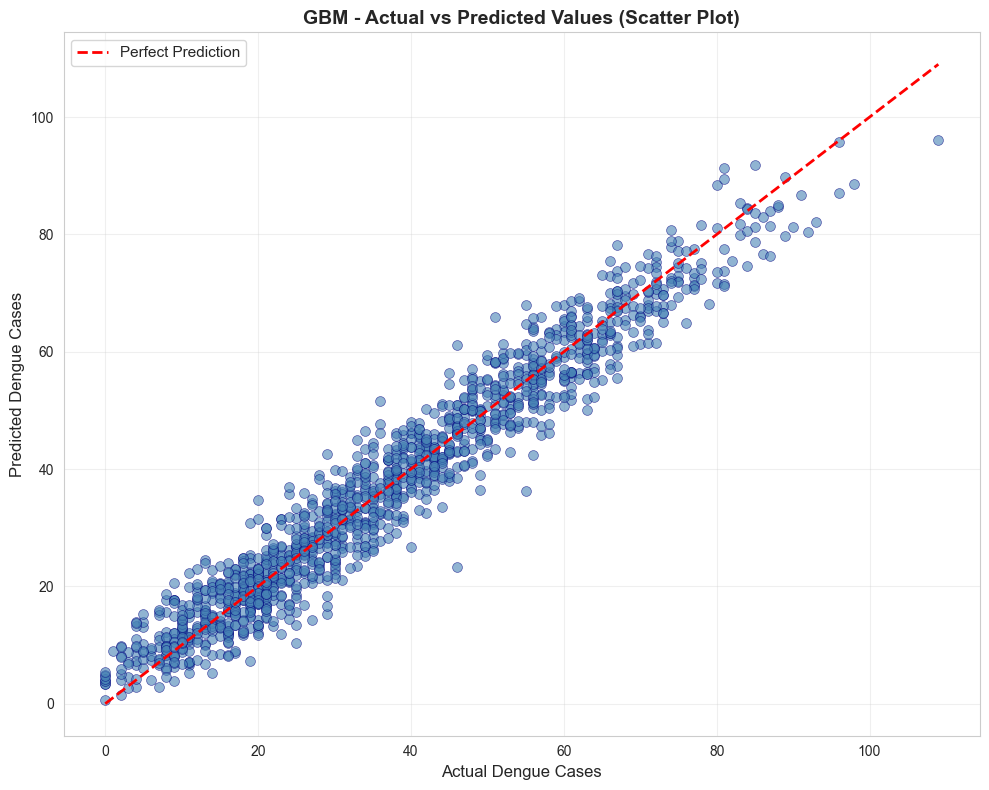

In [115]:
# Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, s=50, color='steelblue', edgecolors='navy', linewidth=0.5)
# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Dengue Cases', fontsize=12)
plt.ylabel('Predicted Dengue Cases', fontsize=12)
plt.title('GBM - Actual vs Predicted Values (Scatter Plot)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

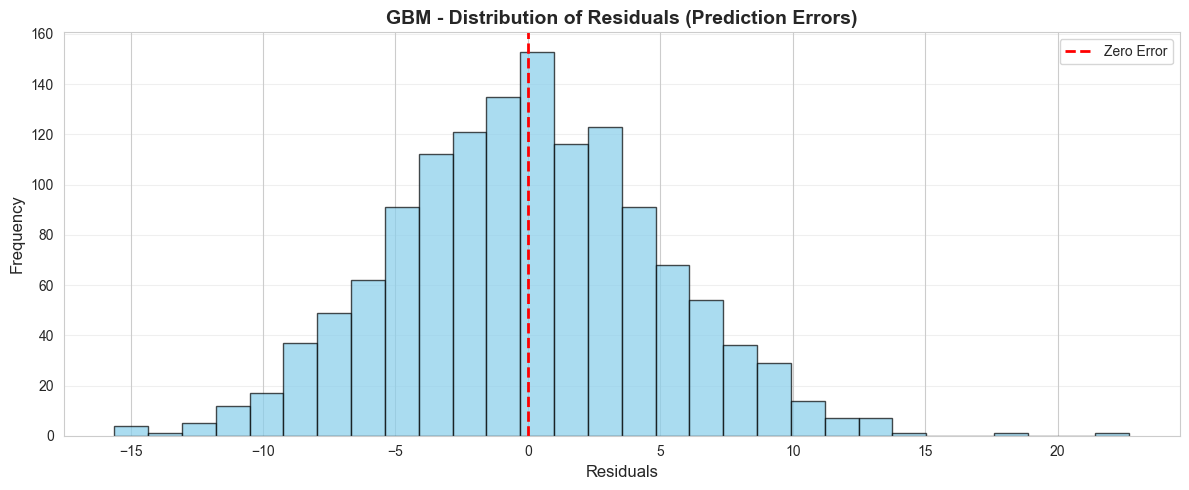

In [116]:
# Distribution of Residuals
plt.figure(figsize=(12, 5))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('GBM - Distribution of Residuals (Prediction Errors)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

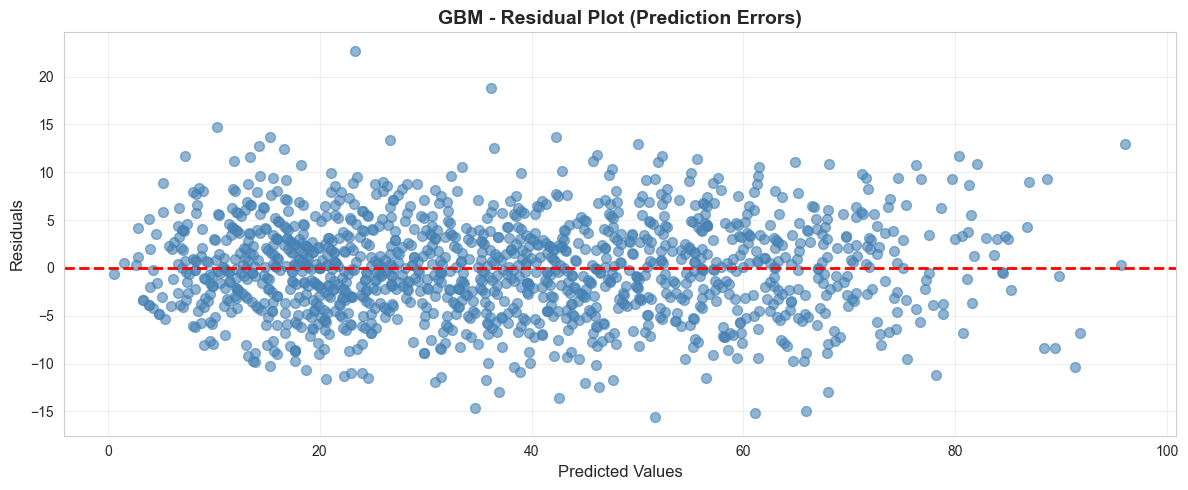

Mean of Residuals: -0.0331
Std Dev of Residuals: 5.0013


In [117]:
# Residuals Plot
residuals = y_test.values - y_pred
plt.figure(figsize=(12, 5))
plt.scatter(y_pred, residuals, alpha=0.6, s=50, color='steelblue')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('GBM - Residual Plot (Prediction Errors)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mean of Residuals: {np.mean(residuals):.4f}')
print(f'Std Dev of Residuals: {np.std(residuals):.4f}')

Plotting Feature Importance...


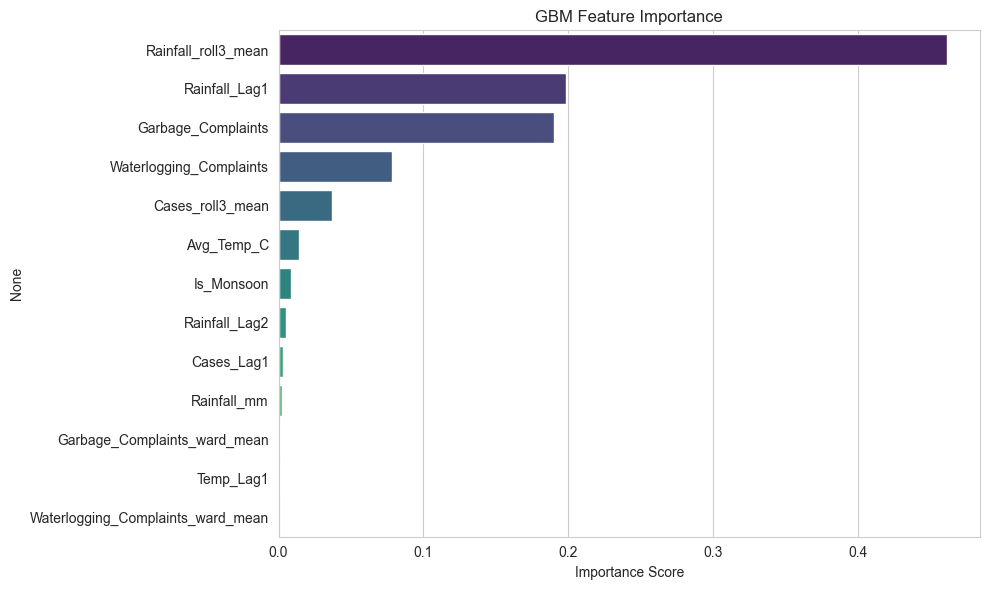

In [ ]:
# Feature Importance Plot - All Models
print('\n' + '='*100)
print('FEATURE IMPORTANCE ANALYSIS FROM ALL MODELS')
print('='*100)

# Collect feature importance from all available models
feature_importance_dict = {}

models_with_importance = ['GBM', 'Random Forest', 'XGBoost']  # Models that have feature_importances_
models_info_fi = {
    'GBM': 'model_gbm.joblib',
    'Random Forest': 'model_random_forest.joblib',
    'XGBoost': 'model_xgboost.joblib'
}

for model_name, model_file in models_info_fi.items():
    try:
        model = joblib.load(model_file)
        feat_importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
        feature_importance_dict[model_name] = feat_importance
        print(f'\n{model_name} - Top 10 Features:')
        print(feat_importance.to_string())
    except:
        print(f"Note: {model_file} not found or does not have feature importance")

# Plot feature importance for all models
if feature_importance_dict:
    n_models = len(feature_importance_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 8))
    
    if n_models == 1:
        axes = [axes]
    
    colors_palette = ['viridis', 'plasma', 'cividis']
    
    for idx, (model_name, feat_importance) in enumerate(feature_importance_dict.items()):
        sns.barplot(x=feat_importance.values, y=feat_importance.index, palette=colors_palette[idx % len(colors_palette)], ax=axes[idx])
        axes[idx].set_title(f'{model_name} - Feature Importance', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Importance Score', fontsize=11)
        axes[idx].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('\n' + '='*100)


In [119]:
# Train GBM Model
print('Training Gradient Boosting Machine (GBM) Model...')
gbm_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbm_model.fit(X_train, y_train)

# Predictions
y_pred = gbm_model.predict(X_test)

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'\n=== GBM Model Results ===')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² Score: {r2:.4f}')

# Save results to dictionary
gbm_results = {
    'model': 'GBM',
    'rmse': rmse,
    'mae': mae,
    'r2': r2
}
print(f'\nResults: {gbm_results}')

Training Gradient Boosting Machine (GBM) Model...

=== GBM Model Results ===
RMSE: 5.0014
MAE: 3.9662
R² Score: 0.9426

Results: {'model': 'GBM', 'rmse': np.float64(5.001440194973941), 'mae': 3.9661831786689823, 'r2': 0.9425861283465324}


In [120]:
# Prepare Data for GBM
features = [
    'Rainfall_mm','Avg_Temp_C','Garbage_Complaints','Waterlogging_Complaints',
    'Rainfall_Lag1','Rainfall_Lag2','Temp_Lag1','Cases_Lag1',
    'Rainfall_roll3_mean','Cases_roll3_mean','Is_Monsoon','Garbage_Complaints_ward_mean','Waterlogging_Complaints_ward_mean'
]
target = 'Dengue_Cases'

X = df_fe[features].copy()
y = df_fe[target].copy()

# Chronological train/test split (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()

print(f'Train rows: {len(X_train)}, Test rows: {len(X_test)}')

Train rows: 5385, Test rows: 1347


In [121]:
# Feature Engineering
df_fe = df.sort_values(['Ward_ID','Date']).reset_index(drop=True).copy()

# Lag features
df_fe['Rainfall_Lag1'] = df_fe.groupby('Ward_ID')['Rainfall_mm'].shift(1)
df_fe['Rainfall_Lag2'] = df_fe.groupby('Ward_ID')['Rainfall_mm'].shift(2)
df_fe['Temp_Lag1'] = df_fe.groupby('Ward_ID')['Avg_Temp_C'].shift(1)
df_fe['Cases_Lag1'] = df_fe.groupby('Ward_ID')['Dengue_Cases'].shift(1)

# Rolling means (3-month)
df_fe['Rainfall_roll3_mean'] = df_fe.groupby('Ward_ID')['Rainfall_mm'].rolling(window=3, min_periods=1).mean().reset_index(0,drop=True)
df_fe['Cases_roll3_mean'] = df_fe.groupby('Ward_ID')['Dengue_Cases'].rolling(window=3, min_periods=1).mean().reset_index(0,drop=True)

# Temporal features
df_fe['Month'] = df_fe['Date'].dt.month
df_fe['Year'] = df_fe['Date'].dt.year
df_fe['Is_Monsoon'] = df_fe['Month'].isin([6,7,8,9]).astype(int)

# Ward-level aggregates
ward_agg = df_fe.groupby('Ward_ID')[['Garbage_Complaints','Waterlogging_Complaints']].mean().rename(columns=lambda x: x+'_ward_mean')
df_fe = df_fe.merge(ward_agg, left_on='Ward_ID', right_index=True)

# Drop NA from lags
df_fe = df_fe.dropna().reset_index(drop=True)
print(f'After Feature Engineering rows: {len(df_fe)}')

After Feature Engineering rows: 6732


In [ ]:
# Load Dataset
df = pd.read_csv('bengaluru_wards_dataset.csv')
print(f'Dataset rows: {len(df)}, columns: {list(df.columns)}')

if 'Date' not in df.columns:
    df['Date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))
else:
    df['Date'] = pd.to_datetime(df['Date'])

print('\nDataset Info:')
df.head()

Dataset rows: 7128, columns: ['Ward_ID', 'Year', 'Month', 'Rainfall_mm', 'Avg_Temp_C', 'Garbage_Complaints', 'Waterlogging_Complaints', 'Dengue_Cases', 'Risk_Level', 'Date']

Dataset Info:


,Ward_ID,Year,Month,Rainfall_mm,Avg_Temp_C,Garbage_Complaints,Waterlogging_Complaints,Dengue_Cases,Risk_Level,Date
0,1,2021,1,5.7,20.4,35,5,22,Medium,2021-01-01
1,1,2021,2,14.5,18.3,25,4,11,Low,2021-02-01
2,1,2021,3,5.1,32.6,20,3,15,Low,2021-03-01
3,1,2021,4,1.2,38.3,21,7,16,Low,2021-04-01
4,1,2021,5,98.0,32.5,20,16,18,Low,2021-05-01


In [123]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [124]:
# Create predictions on test data and aggregate by Ward_ID, Year, and Month
test_pred_df = df_fe.iloc[split_idx:].copy().reset_index(drop=True)
test_pred_df['Predicted_Cases'] = y_pred
test_pred_df['Actual_Cases'] = y_test.values
test_pred_df['Month'] = test_pred_df['Date'].dt.month
test_pred_df['Year'] = test_pred_df['Date'].dt.year

# Load all models and make predictions
models_info = {
    'Linear Regression': 'model_linear_regression.joblib',
    'GBM': 'model_gbm.joblib',
    'Random Forest': 'model_random_forest.joblib',
    'XGBoost': 'model_xgboost.joblib',
    'MLP': 'model_mlp.joblib'
}

all_predictions = []

for model_name, model_file in models_info.items():
    try:
        model = joblib.load(model_file)
        predictions = model.predict(X_test)
        
        # Create dataframe with predictions for this model
        pred_df = test_pred_df.copy()
        pred_df['Model'] = model_name
        pred_df['Predicted_Cases'] = predictions
        
        all_predictions.append(pred_df)
    except:
        print(f"Note: {model_file} not found, skipping {model_name}")

# Combine all predictions
if all_predictions:
    combined_pred_df = pd.concat(all_predictions, ignore_index=True)
    
    # Aggregate by Model, Ward_ID, Year, and Month
    summary = combined_pred_df.groupby(['Model', 'Ward_ID', 'Year', 'Month']).agg({
        'Actual_Cases': 'mean',
        'Predicted_Cases': 'mean'
    }).round(2).reset_index()
    
    summary.columns = ['Model', 'Ward ID', 'Year', 'Month', 'Actual Cases', 'Predicted Cases']
    summary = summary.sort_values(['Model', 'Ward ID', 'Year', 'Month'])
    
    print('\n' + '='*120)
    print('ALL MODELS: PREDICTED DENGUE CASES BY WARD, YEAR AND MONTH')
    print('='*120)
    print(summary.to_string(index=False))
    print('='*120)
else:
    print("No models found to compare. Showing GBM results only:")
    # Fallback to GBM results
    gbm_summary = test_pred_df.copy()
    gbm_summary['Model'] = 'GBM'
    summary = gbm_summary.groupby(['Model', 'Ward_ID', 'Year', 'Month']).agg({
        'Actual_Cases': 'mean',
        'Predicted_Cases': 'mean'
    }).round(2).reset_index()
    
    summary.columns = ['Model', 'Ward ID', 'Year', 'Month', 'Actual Cases', 'Predicted Cases']
    print('\n' + '='*120)
    print('GBM MODEL: PREDICTED DENGUE CASES BY WARD, YEAR AND MONTH')
    print('='*120)
    print(summary.to_string(index=False))
    print('='*120)



ALL MODELS: PREDICTED DENGUE CASES BY WARD, YEAR AND MONTH
            Model  Ward ID  Year  Month  Actual Cases  Predicted Cases
              GBM      159  2022      4          25.0            18.44
              GBM      159  2022      5          19.0            22.40
              GBM      159  2022      6          38.0            38.80
              GBM      159  2022      7          57.0            58.64
              GBM      159  2022      8          65.0            61.97
              GBM      159  2022      9          74.0            77.88
              GBM      159  2022     10          56.0            58.69
              GBM      159  2022     11          49.0            54.95
              GBM      159  2022     12          24.0            35.74
              GBM      159  2023      1          18.0            21.92
              GBM      159  2023      2           4.0             8.54
              GBM      159  2023      3          10.0            16.76
              GBM

In [ ]:
# 1. Model Performance Comparison - Overall Metrics
print('\n' + '='*100)
print('GENERATING MODEL COMPARISON PLOTS...')
print('='*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Load metrics data
if 'combined_pred_df' in locals():
    # Calculate metrics by model
    model_metrics = []
    for model_name, model_file in models_info.items():
        try:
            model = joblib.load(model_file)
            predictions = model.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, predictions))
            mae = mean_absolute_error(y_test, predictions)
            r2 = r2_score(y_test, predictions)
            model_metrics.append({'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2})
        except:
            pass
    
    metrics_comparison = pd.DataFrame(model_metrics)
    
    # Plot 1: RMSE Comparison
    axes[0, 0].bar(metrics_comparison['Model'], metrics_comparison['RMSE'], color='#FF6B6B', alpha=0.8, edgecolor='black')
    axes[0, 0].set_title('Model Comparison: RMSE (Lower is Better)', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('RMSE', fontsize=11)
    axes[0, 0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(metrics_comparison['RMSE']):
        axes[0, 0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')
    
    # Plot 2: MAE Comparison
    axes[0, 1].bar(metrics_comparison['Model'], metrics_comparison['MAE'], color='#4ECDC4', alpha=0.8, edgecolor='black')
    axes[0, 1].set_title('Model Comparison: MAE (Lower is Better)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('MAE', fontsize=11)
    axes[0, 1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(metrics_comparison['MAE']):
        axes[0, 1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')
    
    # Plot 3: R² Comparison
    axes[1, 0].bar(metrics_comparison['Model'], metrics_comparison['R²'], color='#45B7D1', alpha=0.8, edgecolor='black')
    axes[1, 0].set_title('Model Comparison: R² Score (Higher is Better)', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('R² Score', fontsize=11)
    axes[1, 0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(metrics_comparison['R²']):
        axes[1, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
    
    # Plot 4: Model Ranking
    axes[1, 1].axis('off')
    ranking_text = "Model Performance Ranking:\n\n"
    best_r2_model = metrics_comparison.loc[metrics_comparison['R²'].idxmax(), 'Model']
    best_mae_model = metrics_comparison.loc[metrics_comparison['MAE'].idxmin(), 'Model']
    rankings = metrics_comparison.sort_values('R²', ascending=False).reset_index(drop=True)
    for idx, row in rankings.iterrows():
        ranking_text += f"{idx+1}. {row['Model']}: R²={row['R²']:.4f}, MAE={row['MAE']:.2f}\n"
    axes[1, 1].text(0.1, 0.5, ranking_text, fontsize=11, verticalalignment='center', 
                    family='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print('\n' + '='*100)
print('PLOT 1: Model Overall Performance Comparison')
print('='*100)
print(metrics_comparison.to_string(index=False))


In [ ]:
# 2. Model Performance Over Time
if 'combined_pred_df' in locals():
    # Calculate MAE for each model over time (Year-Month)
    combined_pred_df['YearMonth'] = combined_pred_df['Year'].astype(str) + '-' + combined_pred_df['Month'].astype(str).str.zfill(2)
    
    model_time_performance = combined_pred_df.groupby(['Model', 'YearMonth']).apply(
        lambda x: pd.Series({
            'MAE': mean_absolute_error(x['Actual_Cases'], x['Predicted_Cases']),
            'RMSE': np.sqrt(mean_squared_error(x['Actual_Cases'], x['Predicted_Cases'])),
            'R²': r2_score(x['Actual_Cases'], x['Predicted_Cases'])
        })
    ).reset_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: MAE Over Time
    for model in model_time_performance['Model'].unique():
        model_data = model_time_performance[model_time_performance['Model'] == model]
        axes[0].plot(range(len(model_data)), model_data['MAE'], marker='o', label=model, linewidth=2, alpha=0.8)
    
    axes[0].set_title('Model Performance Over Time: MAE (Lower is Better)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Time Period', fontsize=11)
    axes[0].set_ylabel('Mean Absolute Error', fontsize=11)
    axes[0].legend(loc='best', fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: R² Over Time
    for model in model_time_performance['Model'].unique():
        model_data = model_time_performance[model_time_performance['Model'] == model]
        axes[1].plot(range(len(model_data)), model_data['R²'], marker='s', label=model, linewidth=2, alpha=0.8)
    
    axes[1].set_title('Model Performance Over Time: R² Score (Higher is Better)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Time Period', fontsize=11)
    axes[1].set_ylabel('R² Score', fontsize=11)
    axes[1].legend(loc='best', fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print('\n' + '='*100)
    print('PLOT 2: Model Performance Over Time')
    print('='*100)
    print(model_time_performance.to_string(index=False))


In [ ]:
# 3. Ward-Level Model Performance - Identify Best/Worst Performing Wards
if 'combined_pred_df' in locals():
    # Calculate average MAE and R² for each model by Ward
    ward_performance = combined_pred_df.groupby(['Model', 'Ward_ID']).apply(
        lambda x: pd.Series({
            'Avg_MAE': mean_absolute_error(x['Actual_Cases'], x['Predicted_Cases']),
            'Avg_R²': r2_score(x['Actual_Cases'], x['Predicted_Cases'])
        })
    ).reset_index()
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Get specific models for visualization
    models_list = ward_performance['Model'].unique()[:3]  # Top 3 models
    
    # Plot 1: Best Performing Wards (Lowest MAE)
    best_wards = ward_performance.nlargest(10, 'Avg_R²')
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(best_wards)))
    axes[0, 0].barh(range(len(best_wards)), best_wards['Avg_R²'], color=colors, edgecolor='black')
    axes[0, 0].set_yticks(range(len(best_wards)))
    axes[0, 0].set_yticklabels([f"Ward {int(w)} ({m})" for w, m in zip(best_wards['Ward_ID'], best_wards['Model'])], fontsize=9)
    axes[0, 0].set_title('Top 10 Best Performing Ward-Model Combinations (Highest R²)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('R² Score', fontsize=11)
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(best_wards['Avg_R²']):
        axes[0, 0].text(v - 0.01, i, f'{v:.4f}', ha='right', va='center', fontweight='bold', color='white')
    
    # Plot 2: Worst Performing Wards (Highest MAE)
    worst_wards = ward_performance.nlargest(10, 'Avg_MAE')
    colors_bad = plt.cm.Reds(np.linspace(0.4, 0.9, len(worst_wards)))
    axes[0, 1].barh(range(len(worst_wards)), worst_wards['Avg_MAE'], color=colors_bad, edgecolor='black')
    axes[0, 1].set_yticks(range(len(worst_wards)))
    axes[0, 1].set_yticklabels([f"Ward {int(w)} ({m})" for w, m in zip(worst_wards['Ward_ID'], worst_wards['Model'])], fontsize=9)
    axes[0, 1].set_title('Top 10 Worst Performing Ward-Model Combinations (Highest MAE)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Mean Absolute Error', fontsize=11)
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(worst_wards['Avg_MAE']):
        axes[0, 1].text(v + 0.5, i, f'{v:.2f}', ha='left', va='center', fontweight='bold')
    
    # Plot 3: Ward-Level R² Distribution by Model
    ward_r2_by_model = ward_performance.pivot(index='Ward_ID', columns='Model', values='Avg_R²')
    box_data = [ward_r2_by_model[col].dropna() for col in ward_r2_by_model.columns]
    bp = axes[1, 0].boxplot(box_data, labels=ward_r2_by_model.columns, patch_artist=True)
    for patch, color in zip(bp['boxes'], plt.cm.Set3(np.linspace(0, 1, len(bp['boxes'])))):
        patch.set_facecolor(color)
    axes[1, 0].set_title('R² Score Distribution Across Wards by Model', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('R² Score', fontsize=11)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Plot 4: Ward-Level MAE Distribution by Model
    ward_mae_by_model = ward_performance.pivot(index='Ward_ID', columns='Model', values='Avg_MAE')
    box_data_mae = [ward_mae_by_model[col].dropna() for col in ward_mae_by_model.columns]
    bp_mae = axes[1, 1].boxplot(box_data_mae, labels=ward_mae_by_model.columns, patch_artist=True)
    for patch, color in zip(bp_mae['boxes'], plt.cm.Set3(np.linspace(0, 1, len(bp_mae['boxes'])))):
        patch.set_facecolor(color)
    axes[1, 1].set_title('MAE Distribution Across Wards by Model', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Mean Absolute Error', fontsize=11)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print('\n' + '='*100)
    print('PLOT 3: Ward-Level Model Performance Analysis')
    print('='*100)
    print("\nWARD PERFORMANCE STATISTICS:")
    print("="*100)
    print(ward_performance.sort_values('Avg_R²', ascending=False).head(15).to_string(index=False))


In [ ]:
# 4. Temporal Analysis - Identify Best/Worst Time Periods
if 'combined_pred_df' in locals():
    # Calculate performance by Year-Month for all models
    temporal_performance = combined_pred_df.groupby('YearMonth').apply(
        lambda x: pd.Series({
            'Avg_MAE': mean_absolute_error(x['Actual_Cases'], x['Predicted_Cases']),
            'Avg_R²': r2_score(x['Actual_Cases'], x['Predicted_Cases']),
            'Count': len(x)
        })
    ).reset_index()
    
    # Performance by Model and Time
    temporal_by_model = combined_pred_df.groupby(['YearMonth', 'Model']).apply(
        lambda x: pd.Series({
            'MAE': mean_absolute_error(x['Actual_Cases'], x['Predicted_Cases']),
            'R²': r2_score(x['Actual_Cases'], x['Predicted_Cases'])
        })
    ).reset_index()
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Best Time Periods (Highest Avg R²)
    best_times = temporal_performance.nlargest(10, 'Avg_R²')
    colors_time = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(best_times)))
    axes[0, 0].barh(range(len(best_times)), best_times['Avg_R²'], color=colors_time, edgecolor='black')
    axes[0, 0].set_yticks(range(len(best_times)))
    axes[0, 0].set_yticklabels(best_times['YearMonth'], fontsize=10)
    axes[0, 0].set_title('Top 10 Best Time Periods (Highest Avg R²)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Average R² Score', fontsize=11)
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(best_times['Avg_R²']):
        axes[0, 0].text(v - 0.01, i, f'{v:.4f}', ha='right', va='center', fontweight='bold', color='white')
    
    # Plot 2: Worst Time Periods (Highest MAE)
    worst_times = temporal_performance.nlargest(10, 'Avg_MAE')
    colors_time_bad = plt.cm.Reds(np.linspace(0.4, 0.9, len(worst_times)))
    axes[0, 1].barh(range(len(worst_times)), worst_times['Avg_MAE'], color=colors_time_bad, edgecolor='black')
    axes[0, 1].set_yticks(range(len(worst_times)))
    axes[0, 1].set_yticklabels(worst_times['YearMonth'], fontsize=10)
    axes[0, 1].set_title('Top 10 Worst Time Periods (Highest Avg MAE)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Average Mean Absolute Error', fontsize=11)
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(worst_times['Avg_MAE']):
        axes[0, 1].text(v + 0.5, i, f'{v:.2f}', ha='left', va='center', fontweight='bold')
    
    # Plot 3: Model Performance Trends Over Time
    for model in temporal_by_model['Model'].unique():
        model_temporal = temporal_by_model[temporal_by_model['Model'] == model].sort_values('YearMonth')
        axes[1, 0].plot(range(len(model_temporal)), model_temporal['R²'], marker='o', label=model, linewidth=2, alpha=0.8)
    
    axes[1, 0].set_title('R² Score Trend Over Time by Model', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Time Period Index', fontsize=11)
    axes[1, 0].set_ylabel('R² Score', fontsize=11)
    axes[1, 0].legend(loc='best', fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Month-wise Average Performance (seasonal patterns)
    combined_pred_df['Month_Str'] = combined_pred_df['Month'].map({
        1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
        7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
    })
    
    monthly_performance = combined_pred_df.groupby(['Month_Str', 'Model']).apply(
        lambda x: pd.Series({
            'MAE': mean_absolute_error(x['Actual_Cases'], x['Predicted_Cases']),
            'R²': r2_score(x['Actual_Cases'], x['Predicted_Cases'])
        })
    ).reset_index()
    
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthly_pivot = monthly_performance.pivot(index='Month_Str', columns='Model', values='R²')
    monthly_pivot = monthly_pivot.reindex([m for m in month_order if m in monthly_pivot.index])
    
    monthly_pivot.plot(ax=axes[1, 1], marker='o', linewidth=2, markersize=8)
    axes[1, 1].set_title('Seasonal Pattern: Average R² Score by Month', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Month', fontsize=11)
    axes[1, 1].set_ylabel('R² Score', fontsize=11)
    axes[1, 1].legend(loc='best', fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print('\n' + '='*100)
    print('PLOT 4: Temporal Analysis - Best and Worst Performing Time Periods')
    print('='*100)
    print("\nBEST TIME PERIODS:")
    print("="*100)
    print(best_times[['YearMonth', 'Avg_R²', 'Avg_MAE']].to_string(index=False))
    print("\nWORST TIME PERIODS:")
    print("="*100)
    print(worst_times[['YearMonth', 'Avg_R²', 'Avg_MAE']].to_string(index=False))
    print("\nMONTHLY PERFORMANCE PATTERN:")
    print("="*100)
    print(monthly_pivot.to_string())


In [125]:
import plotly.graph_objs as go

# Load and compare all models' performance
metrics_df = pd.read_csv('model_comparison_metrics.csv')

# Create subplots for model comparison
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('RMSE Comparison<br><sub>Lower is Better</sub>', 
                    'MAE Comparison<br><sub>Lower is Better</sub>', 
                    'R² Score Comparison<br><sub>Higher is Better</sub>'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}, {'type': 'bar'}]],
    horizontal_spacing=0.12
)

# Color coding for models
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
model_colors = {model: colors[i % len(colors)] for i, model in enumerate(metrics_df['model'])}

# RMSE comparison
fig.add_trace(
    go.Bar(
        x=metrics_df['model'],
        y=metrics_df['rmse'],
        marker=dict(color=[model_colors[m] for m in metrics_df['model']], opacity=0.8),
        text=metrics_df['rmse'].round(3),
        textposition='outside',
        name='RMSE',
        hovertemplate='<b>%{x}</b><br>RMSE: %{y:.4f}<extra></extra>'
    ),
    row=1, col=1
)

# MAE comparison
fig.add_trace(
    go.Bar(
        x=metrics_df['model'],
        y=metrics_df['mae'],
        marker=dict(color=[model_colors[m] for m in metrics_df['model']], opacity=0.8),
        text=metrics_df['mae'].round(3),
        textposition='outside',
        name='MAE',
        hovertemplate='<b>%{x}</b><br>MAE: %{y:.4f}<extra></extra>',
        showlegend=False
    ),
    row=1, col=2
)

# R² comparison
fig.add_trace(
    go.Bar(
        x=metrics_df['model'],
        y=metrics_df['r2'],
        marker=dict(color=[model_colors[m] for m in metrics_df['model']], opacity=0.8),
        text=metrics_df['r2'].round(4),
        textposition='outside',
        name='R²',
        hovertemplate='<b>%{x}</b><br>R²: %{y:.4f}<extra></extra>',
        showlegend=False
    ),
    row=1, col=3
)

fig.update_layout(
    title_text='<b>Model Performance Comparison: Predicting Dengue Cases</b>',
    height=550,
    width=1400,
    showlegend=False,
    template='plotly_white',
    font=dict(size=11)
)

# Update y-axes labels
fig.update_yaxes(title_text='RMSE', row=1, col=1)
fig.update_yaxes(title_text='MAE', row=1, col=2)
fig.update_yaxes(title_text='R² Score', row=1, col=3)

fig.show()

# Display detailed metrics table
print('\n' + '='*80)
print('MODEL PERFORMANCE METRICS COMPARISON')
print('='*80)
metrics_display = metrics_df.copy()
metrics_display['rmse'] = metrics_display['rmse'].round(4)
metrics_display['mae'] = metrics_display['mae'].round(4)
metrics_display['r2'] = metrics_display['r2'].round(4)
print(metrics_display.to_string(index=False))
print('='*80)
print('\nPerformance Ranking:')
best_rmse = metrics_df.loc[metrics_df['rmse'].idxmin(), 'model']
best_r2 = metrics_df.loc[metrics_df['r2'].idxmax(), 'model']
print(f'✓ Best RMSE (lowest error): {best_rmse} ({metrics_df["rmse"].min():.4f})')
print(f'✓ Best R² Score (best fit): {best_r2} ({metrics_df["r2"].max():.4f})')
print('='*80)


MODEL PERFORMANCE METRICS COMPARISON
        model   rmse    mae     r2
      xgboost 4.9974 3.9850 0.9427
          gbm 5.0014 3.9662 0.9426
          mlp 5.0351 4.0053 0.9418
       linear 5.1923 4.0822 0.9381
random_forest 5.6289 4.5077 0.9273

Performance Ranking:
✓ Best RMSE (lowest error): xgboost (4.9974)
✓ Best R² Score (best fit): xgboost (0.9427)


# Gradient Boosting Machine (GBM) Model - Dengue Prediction

This notebook trains a Gradient Boosting regressor model for dengue case prediction in Bengaluru wards.